In [14]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [1]:
from datasets import Dataset


/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/.myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset =  Dataset.from_json("../datasets/PanTabFact/PanTabFact.json")
dataset

Dataset({
    features: ['id', 'statement', 'label', 'table_caption', 'table_text', 'pandas_code', 'pandas_eval'],
    num_rows: 88223
})

In [3]:
dataset[0]

{'id': 0,
 'statement': 'haroldo be mention as a brazil scorer for 2 different game',
 'label': 1,
 'table_caption': '1919 in brazilian football',
 'table_text': 'date#result#score#brazil scorers#competition\nmay 11 , 1919#w#6 - 0#friedenreich (3) , neco (2) , haroldo#south american championship\nmay 18 , 1919#w#3 - 1#heitor , amílcar , millon#south american championship\nmay 26 , 1919#d#2 - 2#neco (2)#south american championship\nmay 29 , 1919#w#1 - 0#friedenreich#south american championship\njune 1 , 1919#d#3 - 3#haroldo , arlindo (2)#taça roberto cherry\n',
 'pandas_code': "df['brazil scorers'].apply(lambda x: 'haroldo' in x).sum() == 2",
 'pandas_eval': 'True'}

In [3]:
import json
import pandas as pd
from io import StringIO
from tqdm import tqdm

In [5]:
corrects = 0
total = 0


# Validate entries
count = 0
for entry in tqdm(dataset):
    count += 1
    total += 1
    df = pd.read_csv(StringIO(entry['table_text']), delimiter='#')
    pandas_eval = str(bool(eval(entry['pandas_code'])))
    if str(bool(entry['label'])) == str(pandas_eval):
        corrects += 1

print(corrects, total, corrects / total)

  0%|          | 80/88223 [00:00<01:51, 792.40it/s]<string>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
<string>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  1%|          | 537/88223 [00:00<02:00, 725.92it/s]<string>:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
<string>:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  1%|▏         | 1160/88223 [00:01<01:54, 758.65it/s]<string>:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) ins

In [ ]:
print(corrects, total, corrects / total)

In [18]:
dataset.filter(lambda x: True if eval(x['pandas_eval'])==bool(x['label']) else False, num_proc=17)

Filter (num_proc=17): 100%|██████████| 88223/88223 [00:00<00:00, 165513.29 examples/s]


Dataset({
    features: ['id', 'statement', 'label', 'table_caption', 'table_text', 'pandas_code', 'pandas_eval'],
    num_rows: 88223
})

In [105]:
def serialize_table_to_tapex_format(df):
    head_pattern = " col : "
    row_pattern = " row {num} : "
    coll_delimetr = " | "
    
    lin_table = head_pattern+coll_delimetr.join(df.columns)
    for i,row in df.iterrows():
        #print(row_pattern.format(num=i+1))
        lin_table+=row_pattern.format(num=i+1)+coll_delimetr.join(str(r) for r in row.values)
    
    return lin_table

In [6]:
python, в дирректории проекта 2 папки f1 и f2 в f1 файл file.py и init.py. В f2 файл run.py как в run.py импортировать функцию из file.py

SyntaxError: invalid syntax (290219339.py, line 1)

In [7]:
import sys
import os

In [4]:
import sys
import os

# Добавляем корневую директорию проекта в sys.path
sys.path.append(os.path.dirname(os.path.abspath('/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/tests')))

In [9]:
sys.path

['/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/.myenv/lib/python3.10/site-packages',
 '/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/.myenv/lib/python3.10/site-packages/nvidia_cutlass_dsl/python_packages',
 '/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer']

In [5]:
from utils.utils import serialize_table
from utils.doduo.doduo import Doduo, DFColTypeTablewiseDataset
import argparse
from transformers import BertTokenizer

In [7]:
df = pd.read_csv(StringIO(dataset[7746]['table_text']), delimiter='#')

In [11]:
df

,place,player,country,score,to par
0,1,deane beman,united states,68 + 69 = 137,- 3
1,t2,miller barber,united states,67 + 71 = 138,- 2
2,t2,bob murphy,united states,66 + 72 = 138,- 2
3,4,bob rosburg,united states,70 + 69 = 139,- 1
4,t5,charles coody,united states,72 + 68 = 140,e
5,t5,al geiberger,united states,68 + 72 = 140,e
6,t5,george knudson,canada,70 + 70 = 140,e
7,t8,tony jacklin,england,71 + 70 = 141,+ 1
8,t8,johnny miller,united states,71 + 70 = 141,+ 1
9,t8,orville moody,united states,71 + 70 = 141,+ 1


In [9]:
df.shape

(20, 20)

In [8]:
model = "viznet"
device = 'cuda'
model = Doduo(argparse.Namespace(**{'model': model, 'device': device}),basedir='../utils/doduo/')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Some weights of BertForMultiOutputClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
p = DFColTypeTablewiseDataset(df, tokenizer)

    table_id  label_ids                                               data
0          1          0  grand slams australian open french open wimble...
1          1          0  grand slams a a a a 0 / 0 0 - 0 atp masters se...
2          1          0  grand slams 1r a a a 0 / 1 0 - 1 atp masters s...
3          1          0  grand slams 2r a 1r a 0 / 2 1 - 2 atp masters ...
4          1          0  grand slams 1r 3r 2r 3r 0 / 4 5 - 4 atp master...
5          1          0  grand slams 1r 3r 3r 2r 0 / 4 5 - 4 atp master...
6          1          0  grand slams 2r 3r 2r qf 0 / 4 8 - 4 atp master...
7          1          0  grand slams 1r sf 1r 1r 0 / 4 5 - 4 atp master...
8          1          0  grand slams 4r 4r a a 0 / 2 5 - 2 atp masters ...
9          1          0  grand slams 3r 1r 2r 1r 0 / 4 3 - 4 atp master...
10         1          0  grand slams 2r 3r a qf 0 / 3 7 - 3 atp masters...
11         1          0  grand slams 1r 1r 4r qf 0 / 4 7 - 4 atp master...
12         1          0  

In [24]:
len(p.table_df['data_tensor'].to_list()[0])

679

In [9]:
serialize_table(df,description=dataset[7747]['table_caption'],model=model)

   table_id  label_ids                                               data
0         1          0                     1 t2 t2 4 t5 t5 t5 t8 t8 t8 t8
1         1          0  deane beman miller barber bob murphy bob rosbu...
2         1          0  united states united states united states unit...
3         1          0  68 + 69 = 137 67 + 71 = 138 66 + 72 = 138 70 +...
4         1          0              - 3 - 2 - 2 - 1 e e e + 1 + 1 + 1 + 1
1
data torch.Size([1, 133])


'<TABLE><DESCRIPTION>magnus larsson</DESCRIPTION><HEADER><NAME>place</NAME><SEMANTIC_TYPE>rank - 1.0</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["4", "t5", "t8"]</EXAMPLES></HEADER><HEADER><NAME>player</NAME><SEMANTIC_TYPE>name - 1.0</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["tony jacklin", "deane beman", "george knudson"]</EXAMPLES></HEADER><HEADER><NAME>country</NAME><SEMANTIC_TYPE>nationality - 1.0</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["england", "united states", "united states"]</EXAMPLES></HEADER><HEADER><NAME>score</NAME><SEMANTIC_TYPE>weight - 0.98</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["68 + 69 = 137", "68 + 72 = 140", "70 + 70 = 140"]</EXAMPLES></HEADER><HEADER><NAME>to par</NAME><SEMANTIC_TYPE>sex - 0.65</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["+ 1", "- 3", "e"]</EXAMPLES></HEADER></TABLE>'

In [7]:
{'id': 0,
 'statement': 'haroldo be mention as a brazil scorer for 2 different game',
 'label': 1,
 'table_caption': '1919 in brazilian football',
 'table_text': 'date#result#score#brazil scorers#competition\nmay 11 , 1919#w#6 - 0#friedenreich (3) , neco (2) , haroldo#south american championship\nmay 18 , 1919#w#3 - 1#heitor , amílcar , millon#south american championship\nmay 26 , 1919#d#2 - 2#neco (2)#south american championship\nmay 29 , 1919#w#1 - 0#friedenreich#south american championship\njune 1 , 1919#d#3 - 3#haroldo , arlindo (2)#taça roberto cherry\n',
 'pandas_code': "df['brazil scorers'].apply(lambda x: 'haroldo' in x).sum() == 2",
 'pandas_eval': 'True'}



{'id': 0,
 'statement': 'haroldo be mention as a brazil scorer for 2 different game',
 'label': 1,
 'table_caption': '1919 in brazilian football',
 'table_text': 'date#result#score#brazil scorers#competition\nmay 11 , 1919#w#6 - 0#friedenreich (3) , neco (2) , haroldo#south american championship\nmay 18 , 1919#w#3 - 1#heitor , amílcar , millon#south american championship\nmay 26 , 1919#d#2 - 2#neco (2)#south american championship\nmay 29 , 1919#w#1 - 0#friedenreich#south american championship\njune 1 , 1919#d#3 - 3#haroldo , arlindo (2)#taça roberto cherry\n',
 'pandas_code': "df['brazil scorers'].apply(lambda x: 'haroldo' in x).sum() == 2",
 'pandas_eval': 'True'}

In [8]:
pwd

'/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/tests'

In [6]:
import json
import pandas as pd
from io import StringIO
from tqdm import tqdm
from utils.utils import serialize_table
from utils.doduo.doduo import Doduo
import argparse
from functools import partial

def convert_dataset_to_nlsep_format(model,data):
    df = pd.read_csv(StringIO(data['table_text']), delimiter='#')
    data['nlsep_query'] = data['statement'] + ' ' +  serialize_table_to_tapex_format(df)
    data['semtab_query'] = data['statement'] + ' ' + serialize_table(df,model=model, description=data['table_caption'],basedir='../utils/doduo/')
    return data


In [42]:
model_type = "viznet"
device = 'cpu'
model = Doduo(argparse.Namespace(**{'model': model_type, 'device': device}),basedir='../utils/doduo/')
doduo_convert_dataset_to_nlsep_format = partial(convert_dataset_to_nlsep_format,model)


Some weights of BertForMultiOutputClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
model

In [7]:
dataset2 = dataset.map(doduo_convert_dataset_to_nlsep_format)
dataset2.save_to_disk('./new_dataset')

NameError: name 'doduo_convert_dataset_to_nlsep_format' is not defined

In [44]:
dataset2.save_to_disk('./new_dataset')

Saving the dataset (1/1 shards): 100%|██████████| 88223/88223 [00:00<00:00, 549715.04 examples/s]


In [8]:
from datasets import load_from_disk

In [9]:
data = load_from_disk('new_dataset')

In [12]:
data

Dataset({
    features: ['id', 'statement', 'label', 'table_caption', 'table_text', 'pandas_code', 'pandas_eval', 'nlsep_query', 'semtab_query'],
    num_rows: 88223
})

In [13]:
data_false = data.filter(lambda x: True if x['semtab_query']=='None' else False)

Filter: 100%|██████████| 88223/88223 [00:00<00:00, 107486.06 examples/s]


In [56]:
import sys
print(sys.executable)

/media/research/yrl_aida_users/poddubny/poddubnyy/postgraduate/semtab_serializer/.myenv/bin/python


In [16]:
data_false.shape[0]/data.shape[0] *100

0.12128356551012774

In [10]:
data_true = data.filter(lambda x: True if x['semtab_query']!='None' else False)

In [102]:
data_true.save_to_disk('none_filtered_new_dataset')

Saving the dataset (1/1 shards): 100%|██████████| 88116/88116 [00:00<00:00, 96170.74 examples/s]


In [101]:
def name_proto_query(entry):
    entry['proto_query'] = f'{entry["statement"]} {entry["table_text"]}'
    return entry
data = load_from_disk('none_filtered_new_dataset')
data2 = data.map(name_proto_query,num_proc=17)


FileNotFoundError: Directory none_filtered_new_dataset not found

In [103]:
data2.save_to_disk('none_filtered_new_dataset2')

Saving the dataset (1/1 shards): 100%|██████████| 88116/88116 [00:00<00:00, 152881.66 examples/s]


In [105]:
data2[0]

{'id': 0,
 'statement': 'haroldo be mention as a brazil scorer for 2 different game',
 'label': 1,
 'table_caption': '1919 in brazilian football',
 'table_text': 'date#result#score#brazil scorers#competition\nmay 11 , 1919#w#6 - 0#friedenreich (3) , neco (2) , haroldo#south american championship\nmay 18 , 1919#w#3 - 1#heitor , amílcar , millon#south american championship\nmay 26 , 1919#d#2 - 2#neco (2)#south american championship\nmay 29 , 1919#w#1 - 0#friedenreich#south american championship\njune 1 , 1919#d#3 - 3#haroldo , arlindo (2)#taça roberto cherry\n',
 'pandas_code': "df['brazil scorers'].apply(lambda x: 'haroldo' in x).sum() == 2",
 'pandas_eval': 'True',
 'nlsep_query': 'haroldo be mention as a brazil scorer for 2 different game  col : date | result | score | brazil scorers | competition row 1 : may 11 , 1919 | w | 6 - 0 | friedenreich (3) , neco (2) , haroldo | south american championship row 2 : may 18 , 1919 | w | 3 - 1 | heitor , amílcar , millon | south american champio

In [104]:
data_false

NameError: name 'data_false' is not defined

In [11]:
def get_count_df_columns(table_str):
    df = pd.read_csv(StringIO(table_str), delimiter='#')
    return df.shape[1]
dt = data_true.filter(lambda x: True if get_count_df_columns(x['table_text']) > 20 else False,num_proc=10)

In [12]:
print(dt[0]['semtab_query'])

during 1993 - 94 victorian premier league season south melbourne fc did not participate <TABLE><DESCRIPTION>south melbourne fc</DESCRIPTION><HEADER><NAME>competition</NAME><SEMANTIC_TYPE>location - 0.72</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["ofc / afc champions league", "nsl / a - league", "ffv cup"]</EXAMPLES></HEADER><HEADER><NAME>1993 - 94</NAME><SEMANTIC_TYPE>result - 0.81</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "2nd", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>1994 - 95</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "sf", "sf"]</EXAMPLES></HEADER><HEADER><NAME>1995 - 96</NAME><SEMANTIC_TYPE>result - 0.74</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "w", "w"]</EXAMPLES></HEADER><HEADER><NAME>1996 - 97</NAME><SEMANTIC_TYPE>notes - 0.68</SEMANTIC_TYPE><DATA_TYPE>"

In [135]:
import xml.dom.minidom

xml_string = """<TABLE><DESCRIPTION>south melbourne fc</DESCRIPTION><HEADER><NAME>competition</NAME><SEMANTIC_TYPE>location - 0.72</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["ofc / afc champions league", "nsl / a - league", "ffv cup"]</EXAMPLES></HEADER><HEADER><NAME>1993 - 94</NAME><SEMANTIC_TYPE>result - 0.81</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "2nd", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>1994 - 95</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "sf", "sf"]</EXAMPLES></HEADER><HEADER><NAME>1995 - 96</NAME><SEMANTIC_TYPE>result - 0.74</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "w", "w"]</EXAMPLES></HEADER><HEADER><NAME>1996 - 97</NAME><SEMANTIC_TYPE>notes - 0.68</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["sf", "did not participate", "pf"]</EXAMPLES></HEADER><HEADER><NAME>1997 - 98</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["1st", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>1998 - 99</NAME><SEMANTIC_TYPE>result - 0.82</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "competition not held", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>1999 - 2000</NAME><SEMANTIC_TYPE>notes - 0.88</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2000 - 01</NAME><SEMANTIC_TYPE>notes - 0.83</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "1st", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2001 - 02</NAME><SEMANTIC_TYPE>rank - 0.81</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["5th", "did not participate", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2002 - 03</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["dnp", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2003 - 04</NAME><SEMANTIC_TYPE>status - 0.83</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "dnp", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2005</NAME><SEMANTIC_TYPE>status - 0.88</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "pf"]</EXAMPLES></HEADER><HEADER><NAME>2006</NAME><SEMANTIC_TYPE>notes - 0.61</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2007</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2008</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["dnp", "competition not held", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2009</NAME><SEMANTIC_TYPE>result - 0.7</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2010</NAME><SEMANTIC_TYPE>notes - 0.66</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "competition not held", "dnp"]</EXAMPLES></HEADER><HEADER><NAME>2011</NAME><SEMANTIC_TYPE>notes - 0.85</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "4th"]</EXAMPLES></HEADER><HEADER><NAME>2012</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "dnp", "6th"]</EXAMPLES></HEADER><HEADER><NAME>2013</NAME><SEMANTIC_TYPE>notes - 0.55</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "did not participate", "sf"]</EXAMPLES></HEADER><HEADER><NAME>2014</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "-"]</EXAMPLES></HEADER></TABLE>"""

# Парсим строку
dom = xml.dom.minidom.parseString(xml_string)

# Преобразуем в форматированную строку с отступами
pretty_xml_string = dom.toprettyxml()

# Выводим на печать
print(pretty_xml_string)

<?xml version="1.0" ?>
<TABLE>
	<DESCRIPTION>south melbourne fc</DESCRIPTION>
	<HEADER>
		<NAME>competition</NAME>
		<SEMANTIC_TYPE>location - 0.72</SEMANTIC_TYPE>
		<DATA_TYPE>&quot;str&quot;</DATA_TYPE>
		<HAS_NONE>0</HAS_NONE>
		<EXAMPLES>[&quot;ofc / afc champions league&quot;, &quot;nsl / a - league&quot;, &quot;ffv cup&quot;]</EXAMPLES>
	</HEADER>
	<HEADER>
		<NAME>1993 - 94</NAME>
		<SEMANTIC_TYPE>result - 0.81</SEMANTIC_TYPE>
		<DATA_TYPE>&quot;str&quot;</DATA_TYPE>
		<HAS_NONE>0</HAS_NONE>
		<EXAMPLES>[&quot;did not participate&quot;, &quot;2nd&quot;, &quot;did not participate&quot;]</EXAMPLES>
	</HEADER>
	<HEADER>
		<NAME>1994 - 95</NAME>
		<SEMANTIC_TYPE/>
		<DATA_TYPE>&quot;str&quot;</DATA_TYPE>
		<HAS_NONE>0</HAS_NONE>
		<EXAMPLES>[&quot;did not participate&quot;, &quot;sf&quot;, &quot;sf&quot;]</EXAMPLES>
	</HEADER>
	<HEADER>
		<NAME>1995 - 96</NAME>
		<SEMANTIC_TYPE>result - 0.74</SEMANTIC_TYPE>
		<DATA_TYPE>&quot;str&quot;</DATA_TYPE>
		<HAS_NONE>0</HAS_NONE>
		<EXAMPLE

In [132]:
import xml.etree.ElementTree as ET
root = ET.fromstring('<TABLE><DESCRIPTION>south melbourne fc</DESCRIPTION><HEADER><NAME>competition</NAME><SEMANTIC_TYPE>location - 0.72</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["ofc / afc champions league", "nsl / a - league", "ffv cup"]</EXAMPLES></HEADER><HEADER><NAME>1993 - 94</NAME><SEMANTIC_TYPE>result - 0.81</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "2nd", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>1994 - 95</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "sf", "sf"]</EXAMPLES></HEADER><HEADER><NAME>1995 - 96</NAME><SEMANTIC_TYPE>result - 0.74</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "w", "w"]</EXAMPLES></HEADER><HEADER><NAME>1996 - 97</NAME><SEMANTIC_TYPE>notes - 0.68</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["sf", "did not participate", "pf"]</EXAMPLES></HEADER><HEADER><NAME>1997 - 98</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["1st", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>1998 - 99</NAME><SEMANTIC_TYPE>result - 0.82</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "competition not held", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>1999 - 2000</NAME><SEMANTIC_TYPE>notes - 0.88</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2000 - 01</NAME><SEMANTIC_TYPE>notes - 0.83</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "1st", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2001 - 02</NAME><SEMANTIC_TYPE>rank - 0.81</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["5th", "did not participate", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2002 - 03</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["dnp", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2003 - 04</NAME><SEMANTIC_TYPE>status - 0.83</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "dnp", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2005</NAME><SEMANTIC_TYPE>status - 0.88</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "pf"]</EXAMPLES></HEADER><HEADER><NAME>2006</NAME><SEMANTIC_TYPE>notes - 0.61</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2007</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2008</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["dnp", "competition not held", "did not participate"]</EXAMPLES></HEADER><HEADER><NAME>2009</NAME><SEMANTIC_TYPE>result - 0.7</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "did not participate", "competition not held"]</EXAMPLES></HEADER><HEADER><NAME>2010</NAME><SEMANTIC_TYPE>notes - 0.66</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "competition not held", "dnp"]</EXAMPLES></HEADER><HEADER><NAME>2011</NAME><SEMANTIC_TYPE>notes - 0.85</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "4th"]</EXAMPLES></HEADER><HEADER><NAME>2012</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "dnp", "6th"]</EXAMPLES></HEADER><HEADER><NAME>2013</NAME><SEMANTIC_TYPE>notes - 0.55</SEMANTIC_TYPE><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["competition not held", "did not participate", "sf"]</EXAMPLES></HEADER><HEADER><NAME>2014</NAME><SEMANTIC_TYPE /><DATA_TYPE>"str"</DATA_TYPE><HAS_NONE>0</HAS_NONE><EXAMPLES>["did not participate", "did not participate", "-"]</EXAMPLES></HEADER></TABLE>')

In [134]:
print(root)

<Element 'TABLE' at 0x726b3e8705e0>


In [22]:
sep_data_len = []
sem_data_len = []
for data in data_true:
    sep_data_len.append(len(data['nlsep_query']))
    sem_data_len.append(len(data['semtab_query']))

In [45]:
 dif[dif<0].shape

(30487,)

In [23]:
import numpy as np 
sep_data_len = np.array(sep_data_len)
sem_data_len = np.array(sem_data_len)
dif = sem_data_len - sep_data_len
print(max(dif),min(dif),dif.mean(),dif.std())


2317 -6940 71.05049026283535 772.3828916818711


In [46]:
print('Процент примеров превышающих соответствующее семантическое представление',  
      dif[dif<0].shape[0]/dif.shape[0]*100)

Процент примеров превышающих соответствующее семантическое представление 34.598710790321846


In [47]:
print('Процент примеров равных семантическое представление',  
      dif[dif == 0].shape[0]/dif.shape[0]*100)

Процент примеров равных семантическое представление 0.06128285441917473


In [51]:
print('Процент примеров отличающихся не более чем на окно в 50 символов от семантическое представление',  
      dif[(dif <= 100) & (dif >= -100) ].shape[0]/dif.shape[0]*100)

Процент примеров отличающихся не более чем на окно в 50 символов от семантическое представление 9.173135412410913


In [55]:
df_dif = pd.DataFrame({'NL+sep':sep_data_len,'Semantic headers':sem_data_len,'dif':dif}) 

<Axes: >

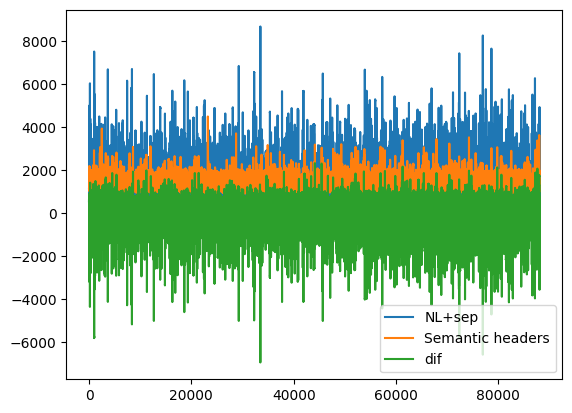

In [57]:
df_dif.plot()

<Axes: >

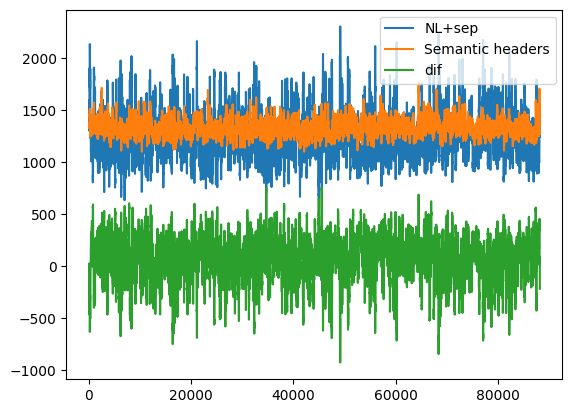

In [56]:
df_dif.rolling(window=100).mean().plot()

In [26]:
pip install matplotlib

  Using cached matplotlib-3.10.7-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.7 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [58]:
pip install modelscope

Note: you may need to restart the kernel to use updated packages.


In [13]:
from modelscope import AutoTokenizer, AutoModelForCausalLM
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/deepseek-coder-7b-instruct-v1.5", trust_remote_code=True)

2025-12-05 14:42:29,424 - modelscope - INFO - Target directory already exists, skipping creation.


In [14]:
def compute_tokens_lenghts(text,tokenizer):
    messages=[
         { 'role': 'system', 'content': ""},
        { 'role': 'user', 'content': text}
    ]
    return tokenizer.apply_chat_template(messages, add_generation_prompt=False, return_tensors="pt").shape[1]

In [15]:
from tqdm import tqdm
sep_data_len_token = []
sem_data_len_token = []

for data in tqdm(data_true):
    sep_data_len_token.append(compute_tokens_lenghts(data['nlsep_query'],tokenizer))
    sem_data_len_token.append(compute_tokens_lenghts(data['semtab_query'],tokenizer))

100%|██████████| 88116/88116 [04:48<00:00, 305.47it/s]


In [16]:
count_columns = []
count_rows = []
for data in tqdm(data_true):
    df = pd.read_csv(StringIO(data['table_text']), delimiter='#')
    count_columns.append(df.shape[1])
    count_rows.append(df.shape[0])

100%|██████████| 88116/88116 [01:12<00:00, 1215.26it/s]


In [17]:
import numpy as np 
sep_data_len_token = np.array(sep_data_len_token)
sem_data_len_token = np.array(sem_data_len_token)
dif_token = sem_data_len_token - sep_data_len_token
print(max(dif_token),min(dif_token),dif_token.mean(),dif_token.std())

1181 -3164 -42.695912206636706 356.9935020599761


In [117]:
k = sem_data_len_token/sep_data_len_token*100

In [118]:
print(k.min(),k.max())

18.242894056847543 481.9742489270387


In [95]:
print('Процент примеров превышающих соответствующее семантическое представление',  
      dif_token[dif_token<0].shape[0]/dif_token.shape[0]*100)
print('Процент примеров равных семантическое представление',  
      dif_token[dif_token == 0].shape[0]/dif_token.shape[0]*100)
print('Процент примеров отличающихся не более чем на окно в 50 токенов от семантическое представление',  
      dif_token[(dif_token <= 50) & (dif_token >= -50) ].shape[0]/dif_token.shape[0]*100)

Процент примеров превышающих соответствующее семантическое представление 42.11266966271733
Процент примеров равных семантическое представление 0.10781242907077035
Процент примеров отличающихся не более чем на окно в 50 токенов от семантическое представление 11.171637387080667


In [74]:
df_dif = pd.DataFrame({'NL+sep':sep_data_len_token,'Semantic headers':sem_data_len_token,
                       'count columns':count_columns,'count rows':count_rows,'percent':100-sem_data_len_token/sep_data_len_token*100,
                      'percent_sem':sep_data_len_token/sem_data_len_token*100}) 

In [75]:
df_dif = df_dif[df_dif['count columns']<=15]

In [76]:
df_dif.describe()

,NL+sep,Semantic headers,count columns,count rows,percent,percent_sem
count,87968.000000,87968.000000,87968.000000,87968.000000,87968.000000,87968.000000
mean,576.994703,533.278942,6.285161,13.368861,-22.597923,108.112814
std,379.407588,123.885545,1.520930,8.560545,59.308091,65.625147
min,114.000000,335.000000,5.000000,2.000000,-305.128205,24.683544
25%,317.000000,440.000000,5.000000,7.000000,-65.555556,60.402685
50%,458.000000,503.000000,6.000000,11.000000,-15.329358,86.708192
75%,723.000000,598.000000,7.000000,17.000000,26.603870,136.246966
max,3872.000000,1899.000000,15.000000,48.000000,81.757106,548.158640


In [63]:
p = df_dif['count rows'].copy()

In [69]:
mask = p<10
p[ p<5] = p*2

In [70]:
p.min()

np.int64(4)

<Axes: >

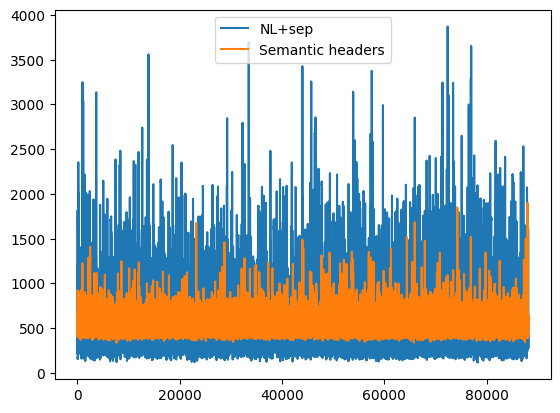

In [99]:
df_dif.plot()

<Axes: >

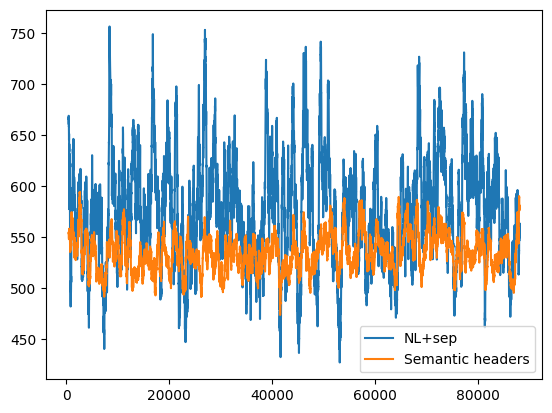

In [101]:
df_dif.rolling(window=500).mean().plot()

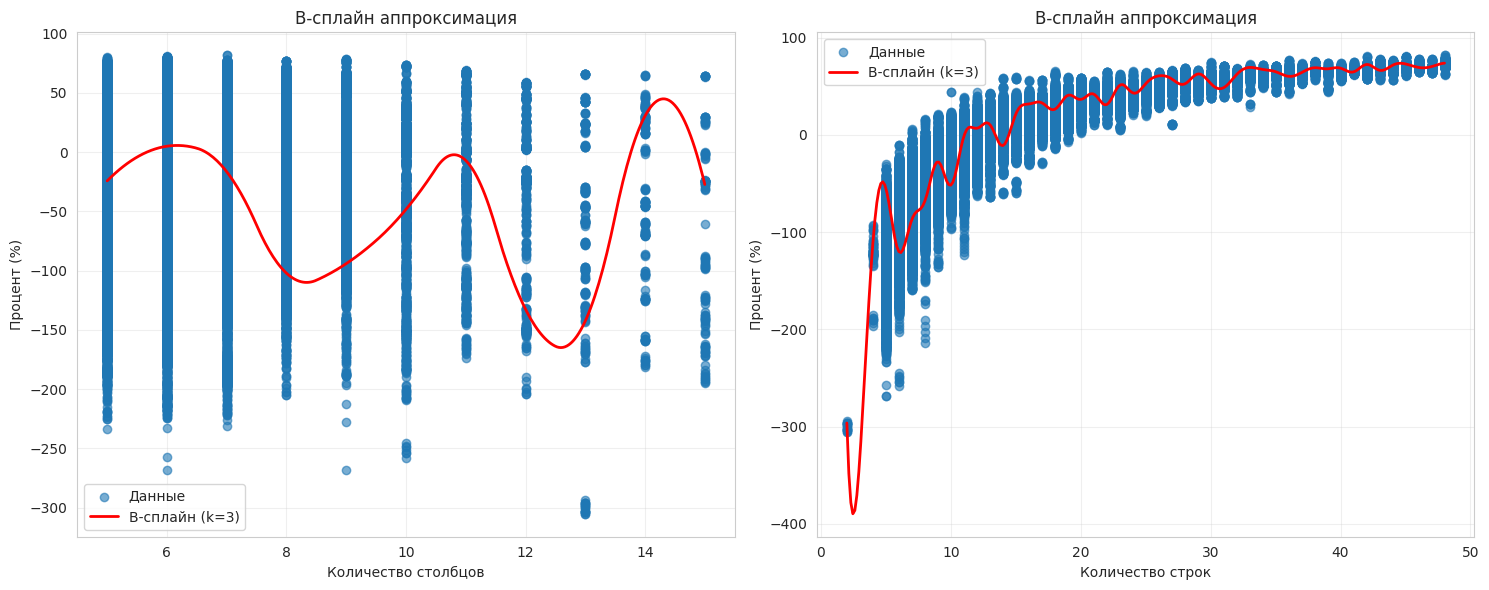

In [29]:
from scipy.interpolate import make_interp_spline, BSpline
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: B-сплайн
x1 = df_dif['count columns'].values
y1 = df_dif['percent'].values

# Сортируем и создаем равномерную сетку
sort_idx = np.argsort(x1)
x1_sorted = x1[sort_idx]
y1_sorted = y1[sort_idx]

# Удаляем дубликаты для сплайна
x1_unique, idx = np.unique(x1_sorted, return_index=True)
y1_unique = y1_sorted[idx]

# Создаем B-сплайн (кубический, k=3)
if len(x1_unique) >= 4:  # B-сплайн требует минимум k+1 точек
    spline1 = make_interp_spline(x1_unique, y1_unique, k=2)  # k=3 для кубического сплайна
    x1_fine = np.linspace(x1_unique.min(), x1_unique.max(), 300)
    
    axes[0].scatter(x1, y1, alpha=0.6, label='Данные')
    axes[0].plot(x1_fine, spline1(x1_fine), 'r-', linewidth=2, label='B-сплайн (k=3)')
else:
    axes[0].scatter(x1, y1, alpha=0.6, label='Данные (недостаточно для сплайна)')

axes[0].set_xlabel('Количество столбцов')
axes[0].set_ylabel('Процент (%)')
axes[0].set_title('B-сплайн аппроксимация')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2
x2 = df_dif['count rows'].values
y2 = df_dif['percent'].values

sort_idx2 = np.argsort(x2)
x2_sorted = x2[sort_idx2]
y2_sorted = y2[sort_idx2]

x2_unique, idx2 = np.unique(x2_sorted, return_index=True)
y2_unique = y2_sorted[idx2]

if len(x2_unique) >= 4:
    spline2 = make_interp_spline(x2_unique, y2_unique, k=4)
    x2_fine = np.linspace(x2_unique.min(), x2_unique.max(), 300)
    
    axes[1].scatter(x2, y2, alpha=0.6, label='Данные')
    axes[1].plot(x2_fine, spline2(x2_fine), 'r-', linewidth=2, label='B-сплайн (k=3)')
else:
    axes[1].scatter(x2, y2, alpha=0.6, label='Данные (недостаточно для сплайна)')

axes[1].set_xlabel('Количество строк')
axes[1].set_ylabel('Процент (%)')
axes[1].set_title('B-сплайн аппроксимация')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


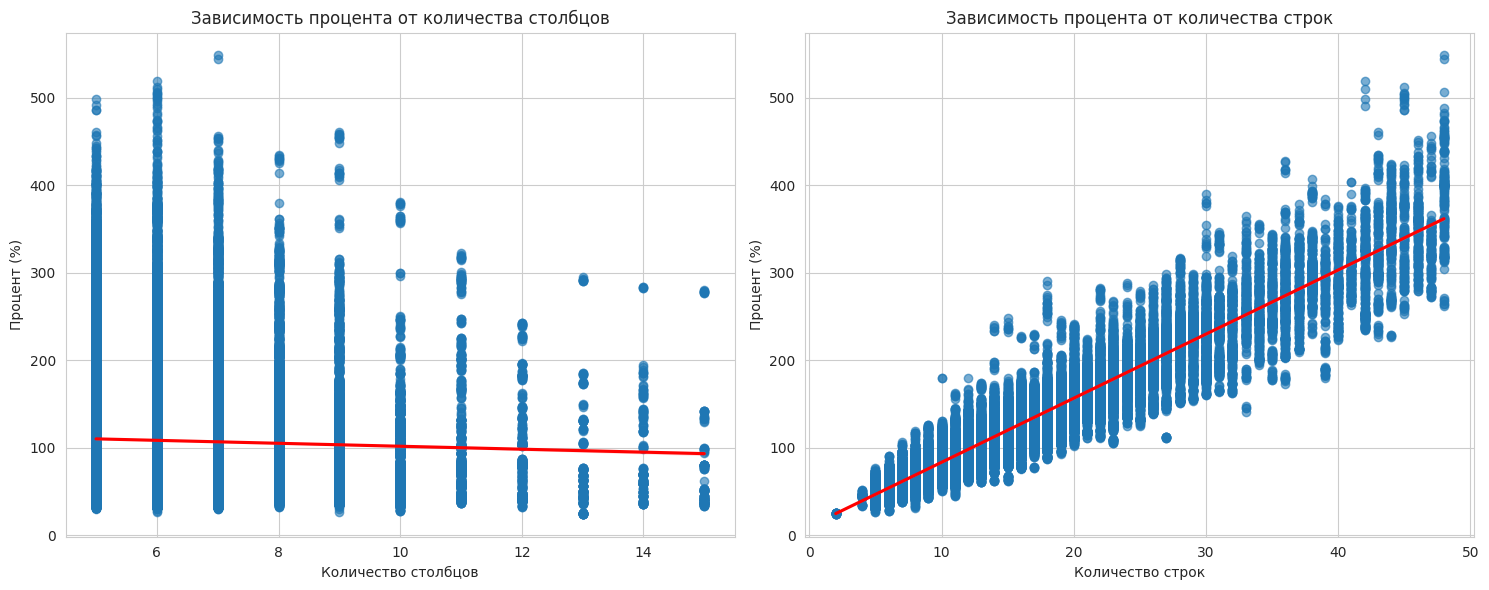

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Первый график с регрессионной линией
sns.regplot(data=df_dif, x='count columns', y='percent_sem', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_xlabel('Количество столбцов')
axes[0].set_ylabel('Процент (%)')
axes[0].set_title('Зависимость процента от количества столбцов')

# Второй график с регрессионной линией
sns.regplot(data=df_dif, x='count rows', y='percent_sem', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_xlabel('Количество строк')
axes[1].set_ylabel('Процент (%)')
axes[1].set_title('Зависимость процента от количества строк')

plt.tight_layout()
plt.show()


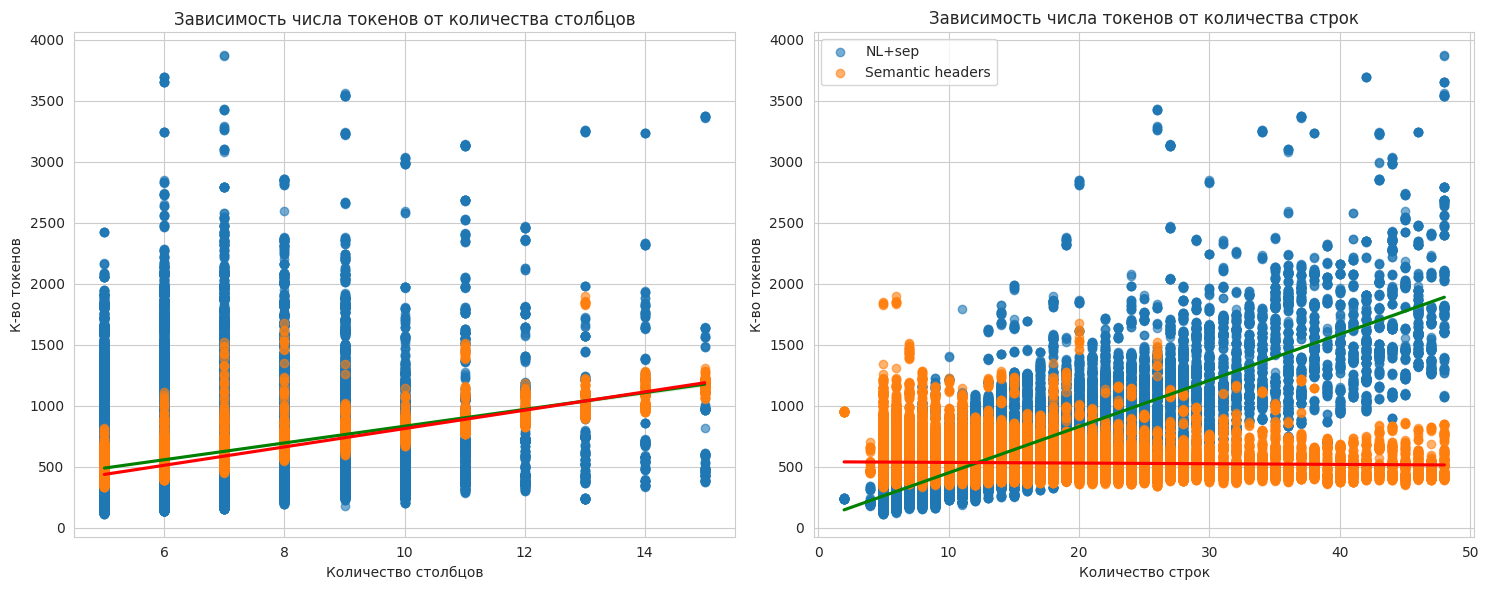

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Первый график с регрессионной линией

sns.regplot(data=df_dif, x='count columns', y='NL+sep', 
            scatter_kws={'alpha': 0.6},  line_kws={'color': 'green'}, ax=axes[0],label = 'NL+sep')
sns.regplot(data=df_dif, x='count columns', y='Semantic headers', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[0],label='Semantic headers')
axes[0].set_xlabel('Количество столбцов')
axes[0].set_ylabel('К-во токенов')
axes[0].set_title('Зависимость числа токенов от количества столбцов')

# Второй график с регрессионной линией

sns.regplot(data=df_dif, x='count rows', y='NL+sep', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'green'}, ax=axes[1],label = 'NL+sep')
sns.regplot(data=df_dif, x='count rows', y='Semantic headers', 
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=axes[1],label='Semantic headers')

axes[1].set_xlabel('Количество строк')
axes[1].set_ylabel('К-во токенов')
axes[1].set_title('Зависимость числа токенов от количества строк')
plt.legend()
plt.tight_layout()
plt.show()


In [161]:
process_data = load_from_disk('answer_gen_none_filtered_new_dataset')

In [164]:
process_data

Dataset({
    features: ['id', 'statement', 'label', 'table_caption', 'table_text', 'pandas_code', 'pandas_eval', 'nlsep_query', 'semtab_query'],
    num_rows: 88116
})

In [20]:
process_data[0]['semtab_query']

NameError: name 'process_data' is not defined

In [ ]:
corrects = 0
total = 0


# Validate entries
def get_accurate(dataset,answ_field):
    corrects = 0
    for entry in tqdm(dataset):
        df = pd.read_csv(StringIO(entry['table_text']), delimiter='#')
        pandas_eval = str(bool(eval(entry['answ_field'])))
        if str(bool(entry['label'])) == str(pandas_eval):
            corrects += 1

print(corrects, total, corrects / total)